# RAID Nesting Trade-offs

Given a fixed number of identical devices, we can arrange them as a single
**RAID 0** (striping) array, or as *nested* RAID 0 arrays — arrays whose members
are themselves arrays. Do these arrangements differ in **sequential read
performance**? And if so, which one is best?

We answer this by enumerating every way of factorising the device count into a
nesting and computing the sequential read performance of each, using the cost
model in `system/storage/RAID/cost_model.py`.

In [1]:
from typing import Iterator

from system.storage.RAID.cost_model import Device, SubSystem, RAID_0

## The cost model, briefly

Every device here is identical, with a sequential read performance of
**100 MB/s**:

In [2]:
def make_device() -> Device:
    """A single identical device: 100 MB/s sequential read/write, 1000 IOPS."""
    return Device(100, 100, 1000, 1000)


make_device().get_sequential_read_performance()

100

For a RAID 0 array, the model defines the **sequential read performance** as

$$\text{read}(\text{RAID 0}) = \min_{m \in \text{members}} \text{read}(m)\; \times\; |\text{members}|,$$

i.e. the slowest member throttles the stripe, multiplied by the number of
members (see `RAID_0.get_sequential_read_performance`). Keep this formula in
mind — it explains everything below.

## Enumerating the nestings

A nesting of $k$ devices is described by a **factorisation** of $k$ into factors
$\ge 2$, e.g. $32 = 4 \cdot 2 \cdot 4$. Each factor is one level of the nesting:
the outermost RAID 0 has (first factor) bare devices plus one nested array, and
so on recursively.

In [3]:
def factorisations(k: int) -> Iterator[list[int]]:
    """Yields every factorisation of ``k`` into factors >= 2 (order matters),
    excluding the trivial single-factor ``[k]``."""
    assert isinstance(k, int) and k >= 1
    for divisor in range(2, k):
        quotient, remainder = divmod(k, divisor)
        if remainder != 0 or quotient < 2:
            continue
        for rest in factorisations(quotient):
            yield [divisor] + rest
        yield [divisor, quotient]


def build_nested_raid_0(config: list[int]) -> SubSystem:
    """Builds a (possibly nested) RAID 0 from a factorisation ``config``:
    the level takes ``config[0]`` bare devices plus the array built from the
    remaining factors."""
    assert len(config) >= 1
    if len(config) == 1:
        return RAID_0([make_device() for _ in range(config[0])])
    inner: SubSystem = build_nested_raid_0(config[1:])
    return RAID_0([make_device() for _ in range(config[0])] + [inner])

In [4]:
import pandas as pd

NUMBER_OF_DEVICES = 32

rows: list[dict] = []
for config in factorisations(NUMBER_OF_DEVICES):
    raid = build_nested_raid_0(config)
    rows.append(
        {
            "nesting": " × ".join(map(str, config)),
            "levels": len(config),
            "top_width": config[0],
            "seq_read_MB_s": raid.get_sequential_read_performance(),
        }
    )

nestings = pd.DataFrame(rows).sort_values(
    "seq_read_MB_s", ascending=False, ignore_index=True
)
nestings

,nesting,levels,top_width,seq_read_MB_s
0,16 × 2,2,16,1700
1,8 × 2 × 2,3,8,900
2,8 × 4,2,8,900
3,4 × 2 × 2 × 2,4,4,500
4,4 × 2 × 4,3,4,500
5,4 × 4 × 2,3,4,500
6,4 × 8,2,4,500
7,2 × 2 × 2 × 2 × 2,5,2,300
8,2 × 2 × 2 × 4,4,2,300
9,2 × 2 × 4 × 2,4,2,300


## What the numbers say

Two things jump out:

1. Every nesting is **far below** the raw total of $32 \times 100 = 3200$ MB/s.
2. The performance depends **only on the top-level width** (the first factor):
   a nesting `a × …` always reaches `100 × (a + 1)` MB/s, regardless of how the
   remaining `…` is arranged.

Both follow directly from the formula. At the outermost level the members are
`a` bare devices (100 MB/s each) plus one nested array. The bare devices make
the **minimum** 100, so the nested array's own (higher) throughput is thrown
away, and the multiplier is just the member count `a + 1`. Nesting therefore
*wastes* devices: everything below the top level collapses into a single member.

In [5]:
# The best nesting found ...
best = nestings.iloc[0]
# ... versus simply striping all devices in one flat RAID 0.
flat = RAID_0([make_device() for _ in range(NUMBER_OF_DEVICES)])
print(f"best nesting: {best['nesting']:>12}  ->  {best['seq_read_MB_s']} MB/s")
print(
    f"flat RAID 0 of {NUMBER_OF_DEVICES}:      ->  "
    f"{flat.get_sequential_read_performance()} MB/s"
)

best nesting:       16 × 2  ->  1700 MB/s
flat RAID 0 of 32:      ->  3200 MB/s


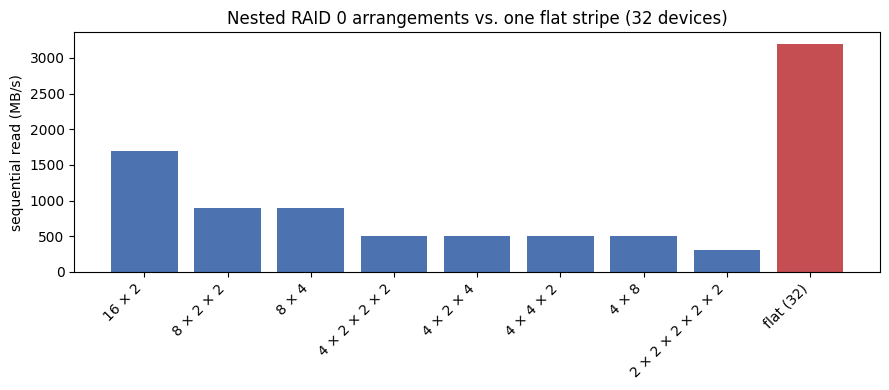

In [6]:
import matplotlib.pyplot as plt

top = nestings.head(8)
labels = list(top["nesting"]) + [f"flat ({NUMBER_OF_DEVICES})"]
values = list(top["seq_read_MB_s"]) + [flat.get_sequential_read_performance()]
colors = ["#4C72B0"] * len(top) + ["#C44E52"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, values, color=colors)
ax.set_ylabel("sequential read (MB/s)")
ax.set_title("Nested RAID 0 arrangements vs. one flat stripe (32 devices)")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
fig.tight_layout()
plt.show()

## Takeaway

For **sequential reads**, a single wide RAID 0 stripe beats every nested
arrangement of the same devices. Nesting only ever helps when a level adds
something the flat stripe cannot — for example **resilience** (a RAID 1 mirror
or a parity level), which trades throughput or capacity for fault tolerance.
Striping alone has no such reason to nest.